---
title: 'Session 10: Data Science Capstone Project'
author: "Dr Kanishka Bhattacharya"
date: "`r Sys.Date()`"
output: 
    html_document:
      number_sections: true
      highlight: haddock
      theme: spacelab
      toc: yes
      toc_depth: 2
      toc_float:
        collapsed: false
---



In [3]:
# Converted from R chunk: setup
# R: knitr::opts_chunk$set(echo = TRUE)
# In Jupyter, code is shown by default. Set some display options.
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)




<style>
div.navy1 { background-color:#686868; border-radius: 5px; padding: 20px; border-style: groove; color: #ffffff;}

</style>





In [4]:
# Converted from R chunk: load_libraries
# Original R installed/loaded: tidyverse, Hmisc, ggthemes, janitor, rpart.plot, caret, lubridate
# Python equivalents below.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, KFold, cross_val_score, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.inspection import permutation_importance




# Introduction and learning objectives

<div class = "navy1">
The purpose of this exercise is to build an estimation engine to guide investment decisions in London house market. You will first build machine learning algorithms (and tune them) to estimate the house prices given variety of information about each property. Then, using your algorithm, you will choose 200 houses to invest in out of about 2000 houses on the market at the moment.


<b>Learning objectives</b>
 
<ol type="i">
  <li>Using different data mining algorithms for prediction.</li>
  <li>Dealing with large data sets</li>
  <li>Tuning data mining algorithms</li>
  <li>Interpreting data mining algorithms and deducing importance of variables</li>
  <li>Using results of data mining algorithms to make business decisions</li>
</ol>  
</div>

# Load data

There are two sets of data, i) training data that has the actual prices ii) out of sample data that has the asking prices. Load both data sets. 

Make sure you understand what information each column contains. Note that not all information provided might be useful in predicting house prices, but do not make any assumptions before you decide what information you use in your prediction algorithms.



In [5]:
# Converted from R chunk: read-investigate
# Read in the data
london_house_prices_2019_training = pd.read_csv("training_data_assignment_with_prices.csv")
london_house_prices_2019_out_of_sample = pd.read_csv("test_data_assignment.csv")

print("Training data shape:", london_house_prices_2019_training.shape)
print("First 5 rows of training data:")
print(london_house_prices_2019_training.head())

print("Out-of-sample data shape:", london_house_prices_2019_out_of_sample.shape)
print("First 5 rows of out-of-sample data:")
print(london_house_prices_2019_out_of_sample.head())


Training data shape: (13998, 37)
First 5 rows of training data:
   ID        date  postcode property_type whether_old_or_new freehold_or_leasehold            address1 address2  \
0   2  2019-11-01   SW8 1UY             F                  N                     L  STAMFORD BUILDINGS   FLAT 8   
1   3  2019-08-08  TW10 5DF             F                  N                     L                  73      NaN   
2   4  2019-04-23  TW14 9QY             S                  N                     F                 199      NaN   
3   5  2019-07-05   E12 5AX             F                  N                     L                 72A      NaN   
4   7  2019-09-06  TW14 8AG             S                  N                     F                  40      NaN   

             address3        town local_aut                county postcode_short current_energy_rating  \
0  SOUTH LAMBETH ROAD         NaN    LONDON               LAMBETH            SW8                     E   
1         SHEEN COURT         NaN

# ICE the Data
- fix categorical and datetime variables
- fix incorrect data types, missing values and inconsistent naming
- remove unnecessary columns (cannot be used for modelling and/or low non-null count)
- get summary statistics for numerical and frequencies for categorical


In [6]:
# Fix data types in both data sets
for _df in [london_house_prices_2019_training, london_house_prices_2019_out_of_sample]:
    if "date" in _df.columns:
        _df["date"] = pd.to_datetime(_df["date"], errors="coerce")
    # Convert string columns to categorical
    obj_cols = _df.select_dtypes(include=["object"]).columns
    for c in obj_cols:
        _df[c] = _df[c].astype("category")

# Quick look at the data
print("TRAINING INFO:")
print(london_house_prices_2019_training.info())
print("\nOUT-OF-SAMPLE INFO:")
print(london_house_prices_2019_out_of_sample.info())


TRAINING INFO:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13998 entries, 0 to 13997
Data columns (total 37 columns):
 #   Column                        Non-Null Count  Dtype         
---  ------                        --------------  -----         
 0   ID                            13998 non-null  int64         
 1   date                          13998 non-null  datetime64[ns]
 2   postcode                      13998 non-null  category      
 3   property_type                 13998 non-null  category      
 4   whether_old_or_new            13998 non-null  category      
 5   freehold_or_leasehold         13998 non-null  category      
 6   address1                      13998 non-null  category      
 7   address2                      3186 non-null   category      
 8   address3                      13998 non-null  category      
 9   town                          614 non-null    category      
 10  local_aut                     13998 non-null  category      
 11  county       

In [7]:
# Drop columns from training data that will not be in OOS testing Data set
# Drop town as it is mostly NA in both 
cols_to_drop_train = ["date", "postcode","address1", "address2", "address3", "local_aut", "county", "town"]
london_house_prices_2019_training = london_house_prices_2019_training.drop(
    columns=cols_to_drop_train, errors="ignore").reset_index(drop=True)

# Drop empty columns from OOS data
# Drop town from OOS data as it is mostly NA in both
cols_to_drop_oos = ["date", "postcode","address1", "address2", "address3", "local_aut", "county", "town"]
london_house_prices_2019_out_of_sample = london_house_prices_2019_out_of_sample.drop(
    columns=cols_to_drop_oos, errors="ignore")

# Drop rows with nulls for population in both datasets
london_house_prices_2019_training = london_house_prices_2019_training.dropna(
    subset=["population"]).reset_index(drop=True)
london_house_prices_2019_out_of_sample = london_house_prices_2019_out_of_sample.dropna(
    subset=["population"]).reset_index(drop=True)

# For both datasets, convert the following columns to categorical (because these numerical variables are discreet and behave like categories):
# num_tube_lines, num_rail_lines, num_light_rail_lines, london_zone, number_habitable_rooms
categorical_cols_to_convert = ["num_tube_lines", "num_rail_lines", "num_light_rail_lines", "london_zone", "number_habitable_rooms"]
# Define the order for each ordinal column

ordinal_orders = {
    "num_tube_lines": sorted(london_house_prices_2019_training["num_tube_lines"].dropna().unique()),
    "num_rail_lines": sorted(london_house_prices_2019_training["num_rail_lines"].dropna().unique()),
    "num_light_rail_lines": sorted(london_house_prices_2019_training["num_light_rail_lines"].dropna().unique()),
    "london_zone": sorted(london_house_prices_2019_training["london_zone"].dropna().unique()),
    "number_habitable_rooms": sorted(london_house_prices_2019_training["number_habitable_rooms"].dropna().unique()),
}

for _df in [london_house_prices_2019_training, london_house_prices_2019_out_of_sample]:
    for col in categorical_cols_to_convert:
        if col in _df.columns:
            order = ordinal_orders[col]
            _df[col] = pd.Categorical(_df[col], categories=order, ordered=True)

# Final shapes and column names after cleaning
print("After cleaning, training data shape:", london_house_prices_2019_training.shape)
print("After cleaning, training data columns:", london_house_prices_2019_training.columns.tolist())
print("After cleaning, out-of-sample data shape:", london_house_prices_2019_out_of_sample.shape)
print("After cleaning, out-of-sample data columns:", london_house_prices_2019_out_of_sample.columns.tolist())

After cleaning, training data shape: (13929, 29)
After cleaning, training data columns: ['ID', 'property_type', 'whether_old_or_new', 'freehold_or_leasehold', 'postcode_short', 'current_energy_rating', 'total_floor_area', 'number_habitable_rooms', 'co2_emissions_current', 'co2_emissions_potential', 'energy_consumption_current', 'energy_consumption_potential', 'windows_energy_eff', 'tenure', 'latitude', 'longitude', 'population', 'altitude', 'london_zone', 'nearest_station', 'water_company', 'average_income', 'district', 'price', 'type_of_closest_station', 'num_tube_lines', 'num_rail_lines', 'num_light_rail_lines', 'distance_to_station']
After cleaning, out-of-sample data shape: (1992, 29)
After cleaning, out-of-sample data columns: ['ID', 'property_type', 'whether_old_or_new', 'freehold_or_leasehold', 'postcode_short', 'current_energy_rating', 'total_floor_area', 'number_habitable_rooms', 'co2_emissions_current', 'co2_emissions_potential', 'energy_consumption_current', 'energy_consumpt

## Understanding the variables

### HM Land Registry Data
**ID** -- automatic reference number for sale

**property_type** -- D = Detached, S=Semi-detached, T=terraced, F-Flats/Maisonettes, O=Other

**whether_old_or_new** -- Y = newly built property, N = an established residential building

**freehold_or_leasehold** -- F = freehold, L = leasehold

**postcode_short** -- first part of postcode e.g. SE1

**district** -- nominal area e.g. Kensington and Chelsea

**price** -- sale price stated on the transfer deed


### Energy Performance of Buildings Data

**current_energy_rating** -- linear 'A to G' rating (where A is most and G is least energy efficient)

**total_floor_area** -- total of all enclosed spaces, measured to the internal face of the external walls

**number_habitable_rooms** -- any livable room (bedroom, sitting room, study, dining room etc. incl. non-separated conservatory)

**co2_emissions_current** -- in tonnes/year

**co2_emissions_potential** -- estimated value produced in 12 month period, tonnes/year

**energy_consumption_current** -- current est. value consumed in 12 month period (kWh/m2)

**energy_consumption_potential** -- est. potential value consumption for 12 month period (kWh/m2)

**windows_energy_eff** -- Very Good | Good | Average | Poor | Very Poor (5-1 star ratings on actual certificate)

**tenure** -- Owner-occupied | Rented (social) | Rented (private)


### Postcode data

**population** -- 2011 census population of that postcode

**latitude** -- lat. of centroid of the Postcode

**longitude** -- long. of centroid of the Postode (-ve values are West of the Greenwich meridian)

**altitude** -- height above sea levels (m)

**london_zone** --TfL Travel Zone indicator (London area only)

**nearest_station** -- nearest station to postcode; incl. tube and tram stops for London

**distance_to_station** -- distance to nearest station from postcode (does this factor in the centroid? visualise to confirm)

**water_company** -- name of water company responsible for the postcode

**average_income** -- avg. household income of the MSOA (?) that the postcode is located in


### Tube Information

**type_of_closest_station** -- 'tube'= tube line, 'light rail' = DLR, Overground, 'rail' = everything else

**num_tube_lines** -- number of tube lines that use the closest station

**num_rail_lines** -- number of rail lines that use the closest station

**num_light_rail_lines** -- number of light rail lines that use that station


## Descriptive Statistics for numerical variables

In [8]:
# Get descriptive statistics for numeric columns in training data
# print("Descriptive statistics for training data:")
# print(london_house_prices_2019_training.describe(include='number').T)

## Value Counts for Categorical Data

In [9]:
# Get value counts for categorical columns in training data
# categorical_cols = london_house_prices_2019_training.select_dtypes(include=['category']).columns

#for col in categorical_cols:
 #   print(f"\nValue counts for categorical column '{col}':")
 #   print(london_house_prices_2019_training[col].value_counts())

In [10]:
# Converted from R chunk: split the price data to training and testing
# Create the train/test split (75% training)
# Add all variables to feature_cols and conduct feature selection later
target = "price"
feature_cols = ['property_type', 'whether_old_or_new', 'freehold_or_leasehold', 'postcode_short', 'current_energy_rating', 'total_floor_area', 
                'number_habitable_rooms', 'co2_emissions_current', 'co2_emissions_potential', 'energy_consumption_current', 
                'energy_consumption_potential', 'windows_energy_eff', 'tenure', 'latitude', 'longitude', 'population', 'altitude', 
                'london_zone', 'nearest_station', 'water_company', 'average_income', 'district', 'type_of_closest_station', 'num_tube_lines', 
                'num_rail_lines', 'num_light_rail_lines', 'distance_to_station']

df = london_house_prices_2019_training.copy()
X = df[feature_cols]
y = df[target]

X_train, X_val, y_train, y_val = train_test_split( # Change test to validation for more intuitive coding
    X, y, train_size=0.75, random_state=42
)
print(f"Train size: {X_train.shape}, Validation size: {X_val.shape}")


Train size: (10446, 27), Validation size: (3483, 27)


## Visualising Data; confirming intuitions and summarising learnings

### Visualize and examine the data. What plots could be useful here? What do you learn from these visualizations?



*Useful plots for influential features on London house prices could be:*
*- boxplot of price to detect outliers; anything above or below upper and lower bounds respectively*
*- histogram of house prices to see reasonable y-lim for subsequent visualisations and to create bin sizes*
*- boxplot of house prices grouped by bivariate categorical variables to see where features should be interacted, combined or dropped*
*- scatter plots and correlation map (given but will redo with seaborn for better interpretability) for bivariate numerical variables*

*Intuitively, house prices would be affected by property type (detached houses have more space therefore higher value), london zone (access to resources and reduced commute to work), distance to station (work commute).*

*What would be interesting to explore is the effect of house price depening on the type of closest station, current energy rating, and water company. For numerical data it would also be interesting to consider the distribution of price by co2 metrics (potential and current), energy metrics (potential and current) and altitude.*

In [11]:
# Converted from R chunk: visualize
# (The original R chunk is empty. Add your EDA plots here if desired.)
# Example (uncomment if you want quick checks):
# _ = X_train["distance_to_station"].hist(bins=50)
# plt.title("Distribution: distance_to_station")
# plt.show()


## EDA on Intuitive relationships with Price

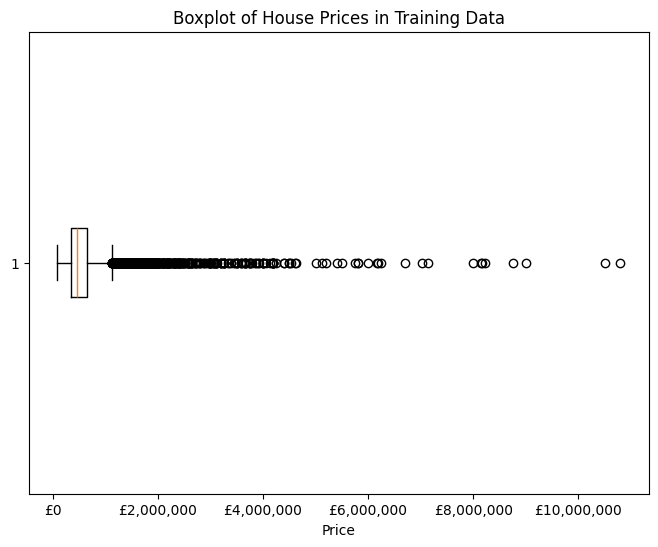

In [12]:
# Boxplot of prices to set limit for outliers
plt.figure(figsize=(8,6))
plt.boxplot(y_train, vert=False)
plt.title("Boxplot of House Prices in Training Data")
plt.xlabel("Price")
# Set the x-axis scale to money format
import matplotlib.ticker as mtick
plt.gca().xaxis.set_major_formatter(mtick.StrMethodFormatter('£{x:,.0f}'))
plt.show()

# Anything above approximately £2,000,000 could be considered an outlier based on this boxplot, however visualising the 
# distribution of prices will give a better idea of outliers.

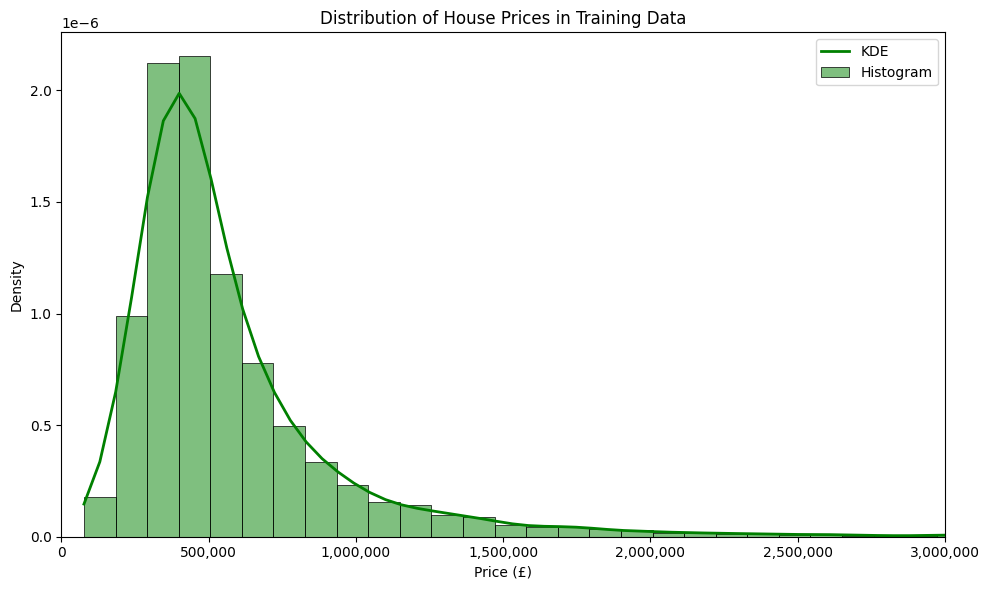

In [13]:
# Import seaborn for cleaner visualisations
import seaborn as sns

plt.figure(figsize=(10,6))

# Plot distribution of target variable 'price'
sns.histplot(
    y_train, 
    bins=100,
    kde=True,
    color='green',
    edgecolor='black',
    alpha=0.5,
    stat='density',
    line_kws={'color': 'darkgreen', 'linewidth': 2} # KDE line colour and style (money-themed; obviously!)
) 

plt.xlim(0, 3000000)  # Limit x-axis to focus on main distribution
plt.title("Distribution of House Prices in Training Data")
plt.grid(False)
plt.legend(["KDE", "Histogram"]) 
plt.gca().xaxis.set_major_formatter(mtick.StrMethodFormatter('{x:,.0f}')) # set x axis scale to money format
plt.xlabel("Price (£)") 
plt.tight_layout() # Adjust layout to prevent clipping
plt.show()

# KDE plot confirms that prices are right-skewed with a long tail to the right, indicating some high-value properties but most of said properties 
# are outside the main distribution. For investment portfolio, select from 90% median range to avoid downside risk from extreme outliers.

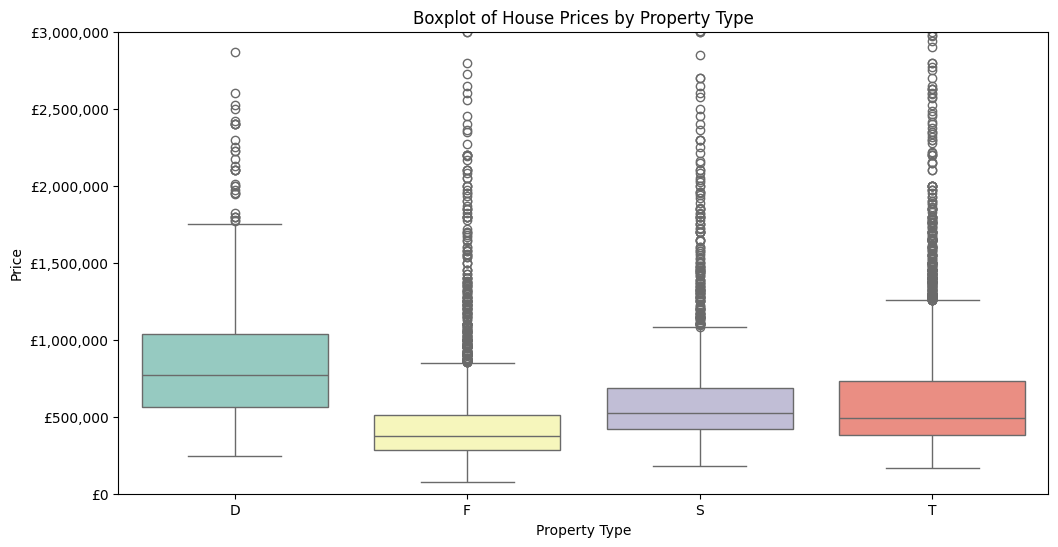

In [14]:
# boxplot of house prices by property type
plt.figure(figsize=(12,6))
sns.boxplot(
    x=X_train["property_type"], 
    y=y_train,
    palette="Set3"
)
plt.title("Boxplot of House Prices by Property Type")
plt.ylim(0, 3000000)  # Limit y-axis to focus on main distribution
plt.ylabel("Price")
plt.xlabel("Property Type")
# set y axis scale to money format
import matplotlib.ticker as mtick
plt.gca().yaxis.set_major_formatter(mtick.StrMethodFormatter('£{x:,.0f}'))
plt.show()

# Confirms that property type has a significant impact on price, with flats generally being cheaper than terraced, 
# semi-detached, and detached houses. Detached houses are the smallest group from this data set, ~800, which should
# not detract from the robustness of the assumption.

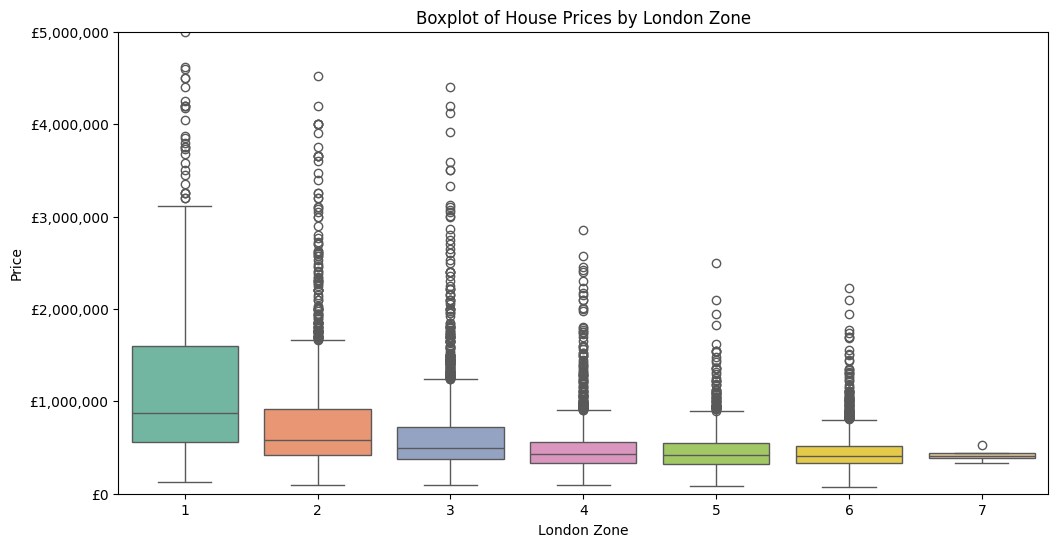

In [15]:
# Boxplot of house prices by London zone
plt.figure(figsize=(12,6))
sns.boxplot(
    x=X_train["london_zone"], 
    y=y_train,
    palette="Set2"
)
plt.title("Boxplot of House Prices by London Zone")
plt.ylim(0, 5000000)  # Limit y-axis to see extend of prices in central zones
plt.ylabel("Price")
plt.xlabel("London Zone")
# set y axis scale to money format
import matplotlib.ticker as mtick
plt.gca().yaxis.set_major_formatter(mtick.StrMethodFormatter('£{x:,.0f}'))
plt.show()

# Confirms that London zone significantly affects house prices, with central zones (1-3) having higher prices compared to 
# outer zones (4-6). However there are significantly fewer observations located in zones 1 (~500) and 7 (<10) thus their distribution
# does not accurately reflect the impact of those locations on house pricing 

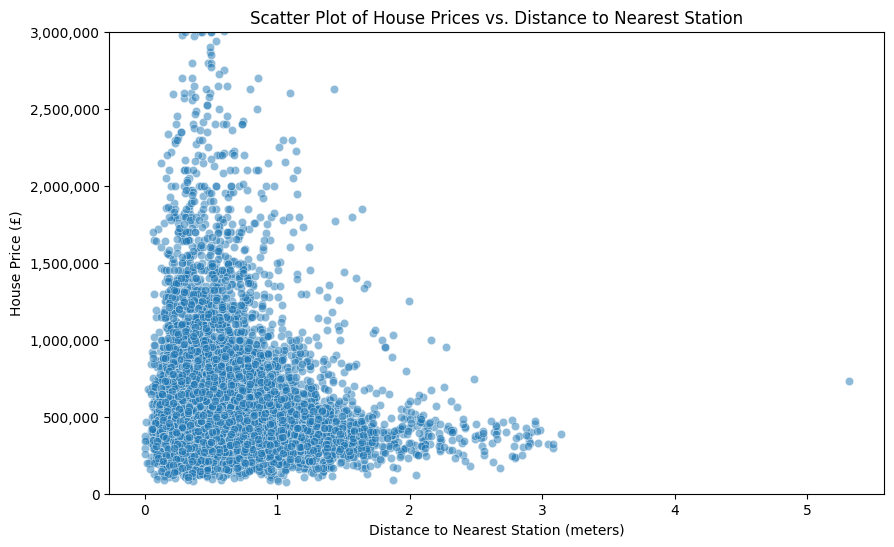

In [16]:
# Distribution of house prices by distance to nearest station
plt.figure(figsize=(10,6))
sns.scatterplot(
    x=X_train["distance_to_station"], 
    y=y_train,
    alpha=0.5
)
plt.title("Scatter Plot of House Prices vs. Distance to Nearest Station")
plt.xlabel("Distance to Nearest Station (meters)")
plt.ylabel("House Price (£)")
# set y axis scale to money format
import matplotlib.ticker as mtick
plt.gca().yaxis.set_major_formatter(mtick.StrMethodFormatter('{x:,.0f}'))
plt.ylim(0, 3000000)  # Limit y-axis to focus on main distribution
plt.show()

# Shows a weak negative correlation between distance to nearest station and house prices, indicating that properties closer 
# to stations tend to be more expensive. However, there is considerable variability in prices at all distances.

## Further EDA

What would be interesting to explore is the effect of the **type of closest station, current energy rating,** and **water company**. For numerical data it would also be interesting to consider the distribution of price by **co2 metrics, energy metrics** and **altitude**.

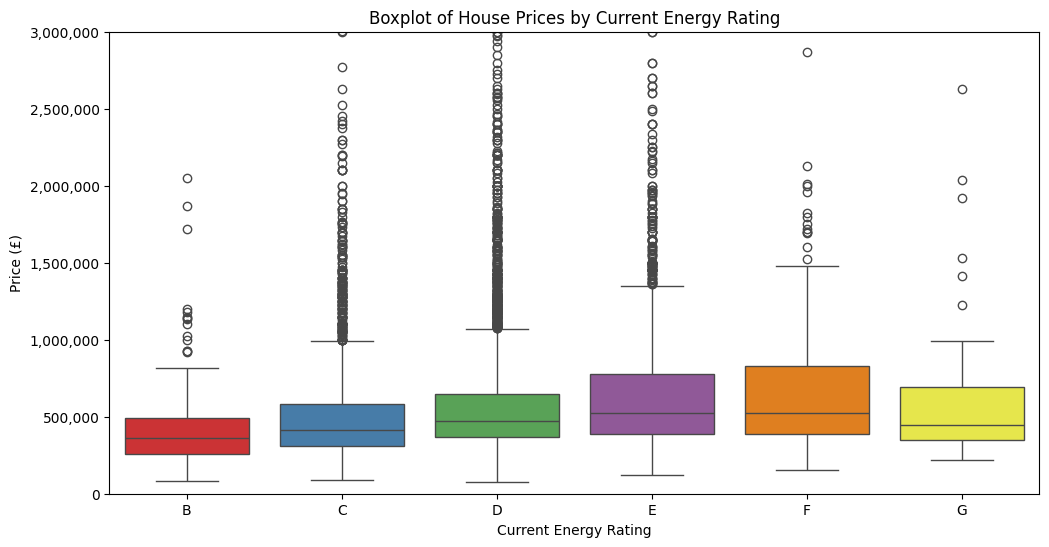

In [17]:
# boxplot of prices by current energy rating
plt.figure(figsize=(12,6))
sns.boxplot(
    x=X_train["current_energy_rating"], 
    y=y_train,
    palette="Set1"
)
plt.title("Boxplot of House Prices by Current Energy Rating")
plt.ylim(0, 3000000)  # Limit y-axis to focus on main distribution
plt.ylabel("Price (£)")
plt.xlabel("Current Energy Rating")
# set y axis scale to money format
plt.gca().yaxis.set_major_formatter(mtick.StrMethodFormatter('{x:,.0f}'))
plt.show()

# Indicates that, save for G, lower energy ratings tend to be associated with higher house prices. This could be due to 
# larger, older properties being less energy efficient but more expensive due to architectural features or location. 
# Equally this could be at least partially explained by the significantly lower count of properties with B, F and G 
# ratings.

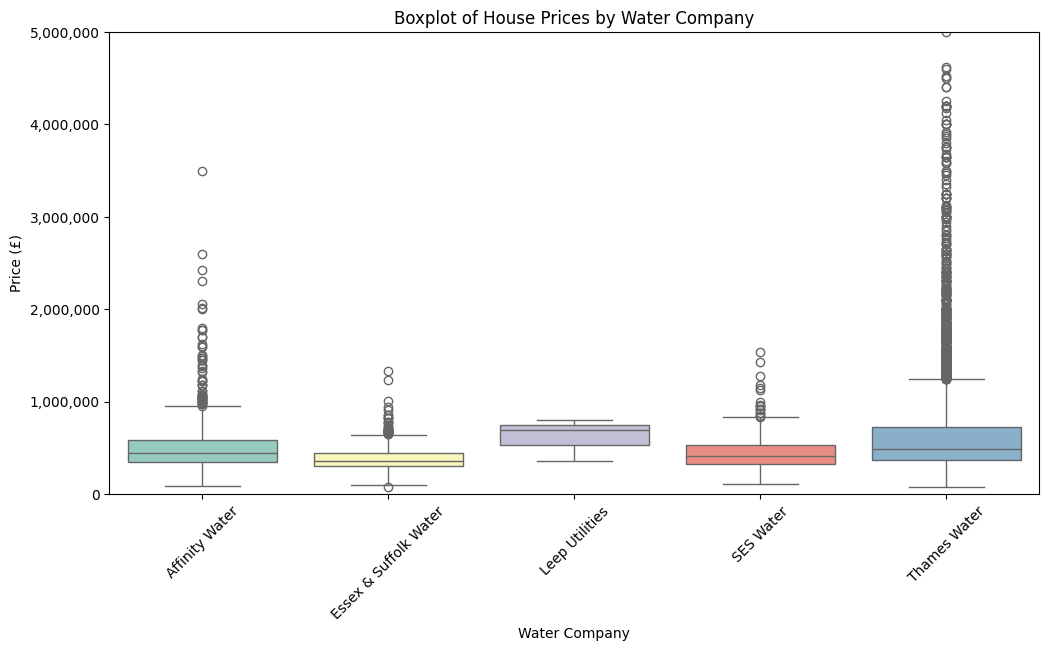

In [18]:
# house prices by water company
plt.figure(figsize=(12,6))
sns.boxplot(
    x=X_train["water_company"], 
    y=y_train,
    palette="Set3"
)
plt.title("Boxplot of House Prices by Water Company")
plt.ylim(0, 5000000)  # Limit y-axis to focus on main distribution while showing extent of outliers
plt.ylabel("Price (£)")
plt.xlabel("Water Company")
# set y axis scale to money format
plt.gca().yaxis.set_major_formatter(mtick.StrMethodFormatter('{x:,.0f}'))
plt.xticks(rotation=45)
plt.show()

# Suggests that water companies may have some influence on house prices, potentially due to differences in water quality, 
# service reliability, or regional factors associated with different water companies. However, the effect is less 
# pronounced compared to other factors like property type or London zone. So perhaps the water reflects the variety of factors like annual income
# by geographical location. Analysis of feature importance later will help clarify this.
# Consider that Thames Water services a large portion of London (~10/13 observations in dataset), so its wide price range may reflect the 
# diversity of properties it serves.Leep only service 7 properties in the training data, so its price range may not be representative.

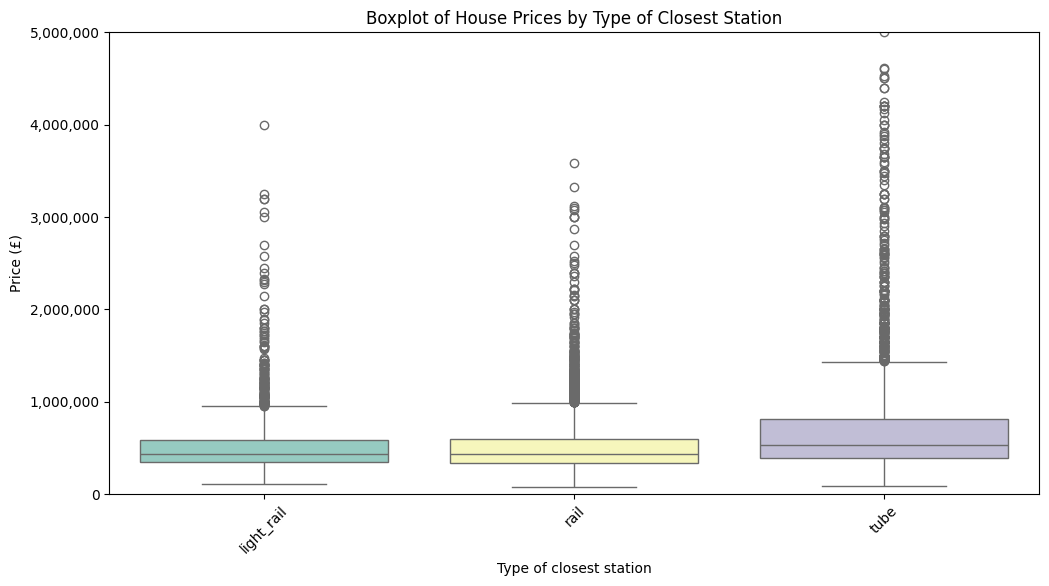

In [19]:
# boxplot of prices by type of closest station

plt.figure(figsize=(12,6))
sns.boxplot(
    x=X_train["type_of_closest_station"], 
    y=y_train,
    palette="Set3"
)
plt.title("Boxplot of House Prices by Type of Closest Station")
plt.ylim(0, 5000000)  # Limit y-axis to focus on main distribution while showing extent of outliers
plt.ylabel("Price (£)")
plt.xlabel("Type of closest station")
# set y axis scale to money format
plt.gca().yaxis.set_major_formatter(mtick.StrMethodFormatter('{x:,.0f}'))
plt.xticks(rotation=45)
plt.show()

# There is a greater range of house prices when tube is the closest nearest station. This is likely correlated with the 
# predictive power of the property's London Zone; homes with greater access to the city centre are likely to be priced 
# at a higher value.

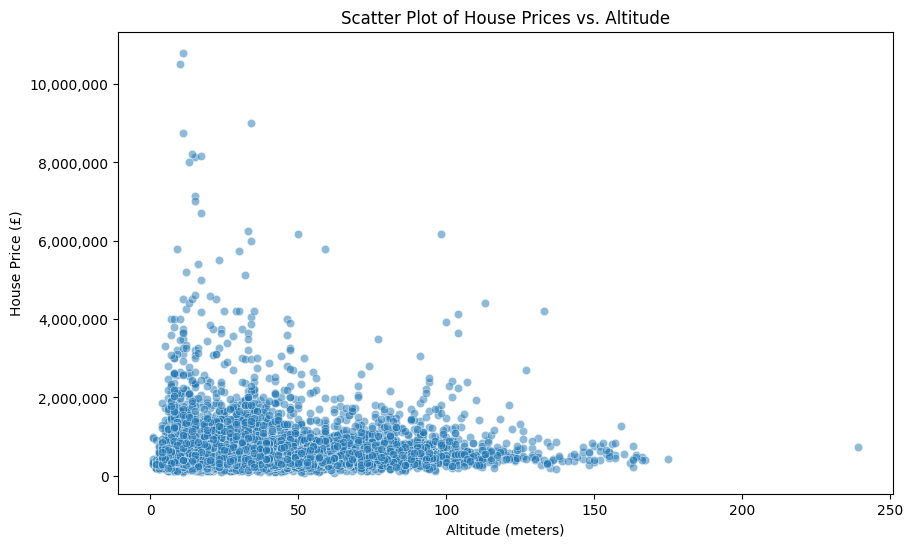

In [20]:
# scatter plot of house prices by altitude
plt.figure(figsize=(10,6))
sns.scatterplot(
    x=X_train["altitude"], 
    y=y_train,
    alpha=0.5
)
plt.title("Scatter Plot of House Prices vs. Altitude")
plt.xlabel("Altitude (meters)")
plt.ylabel("House Price (£)")
# set y axis scale to money format
plt.gca().yaxis.set_major_formatter(mtick.StrMethodFormatter('{x:,.0f}'))
plt.show()

# Shows a weak negative correlation between altitude and house prices, suggesting that properties at lower altitudes may 
# be slightly more expensive.  However, the relationship is not very strong, indicating that altitude does not have as much predictice power
# as other variables. Feature importance analysis later will help clarify this.

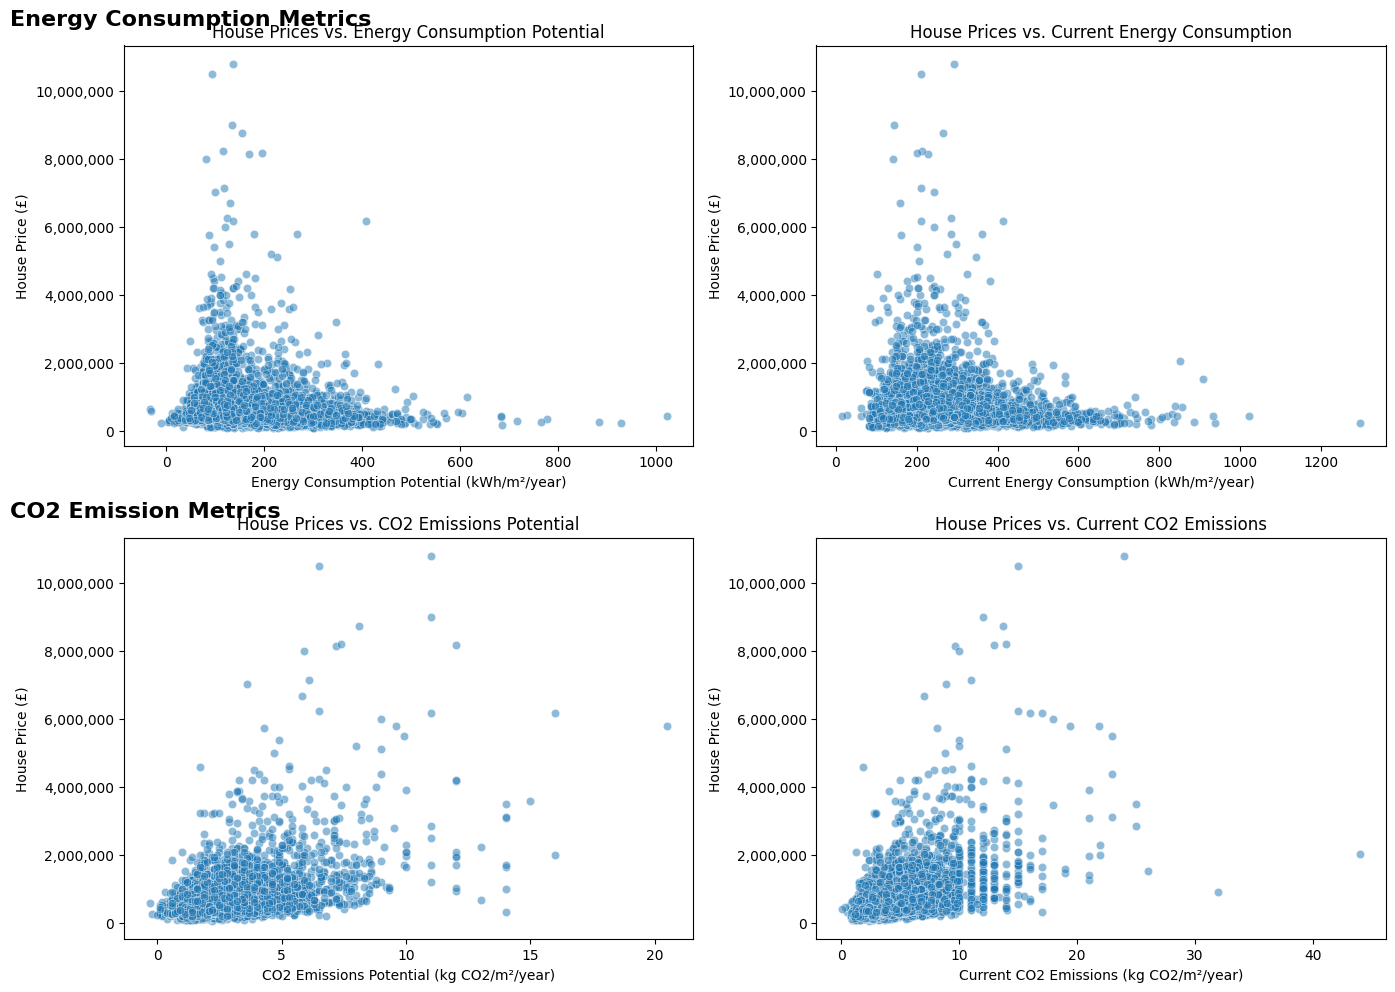

In [21]:
# Plots of house prices by energy consumption potential, current energy consumption, co2 emissions potential and current co2 emissions
# Create a 2x2 grid of scatter plots
fig, axs = plt.subplots(2, 2, figsize=(14, 10))

# Scatter plot for energy consumption potential
sns.scatterplot(
    x=X_train["energy_consumption_potential"], 
    y=y_train,
    alpha=0.5,
    ax=axs[0, 0]
)
axs[0, 0].set_title("House Prices vs. Energy Consumption Potential")
axs[0, 0].set_xlabel("Energy Consumption Potential (kWh/m²/year)")
axs[0, 0].set_ylabel("House Price (£)") 

# Scatter plot for current energy consumption
sns.scatterplot(
    x=X_train["energy_consumption_current"], 
    y=y_train,
    alpha=0.5,
    ax=axs[0, 1]
)
axs[0, 1].set_title("House Prices vs. Current Energy Consumption")
axs[0, 1].set_xlabel("Current Energy Consumption (kWh/m²/year)")
axs[0, 1].set_ylabel("House Price (£)") 

# Scatter plot for CO2 emissions potential
sns.scatterplot(
    x=X_train["co2_emissions_potential"], 
    y=y_train,
    alpha=0.5,
    ax=axs[1, 0]
)
axs[1, 0].set_title("House Prices vs. CO2 Emissions Potential")
axs[1, 0].set_xlabel("CO2 Emissions Potential (kg CO2/m²/year)")
axs[1, 0].set_ylabel("House Price (£)") 

# Scatter plot for current CO2 emissions
sns.scatterplot(
    x=X_train["co2_emissions_current"], 
    y=y_train,
    alpha=0.5,
    ax=axs[1, 1]
)
axs[1, 1].set_title("House Prices vs. Current CO2 Emissions")
axs[1, 1].set_xlabel("Current CO2 Emissions (kg CO2/m²/year)")
axs[1, 1].set_ylabel("House Price (£)")

# Set y axis scale to money format for all subplots
for ax in axs.flat:
    ax.yaxis.set_major_formatter(mtick.StrMethodFormatter('{x:,.0f}'))

# Label top row as "Energy Consumption" and bottom row as "CO2 Emissions"
axs[0, 0].text(-0.2, 1.05, "Energy Consumption Metrics", transform=axs[0, 0].transAxes, fontsize=16, fontweight='bold')
axs[1, 0].text(-0.2, 1.05, "CO2 Emission Metrics", transform=axs[1, 0].transAxes, fontsize=16, fontweight='bold')

# Adjust layout and show plot
plt.tight_layout()
plt.show()

# Shows weak negative correlations between house prices and energy consumption, suggesting that more energy-efficient
# properties tend to be more expensive. However, the relationship is not very strong, indicating that energy consumption is reflecting the 
# predictive power of other variables i.e has multicolinearity. Feature importance analysis later will help clarify this, again.
# Shows weak positive correlations between house prices and CO2 emissions, suggesting that properties with higher 
# emissions tend to be slightly more expensive. 




Estimate a correlation table between prices and other continuous variables. What do you glean from the correlation table?



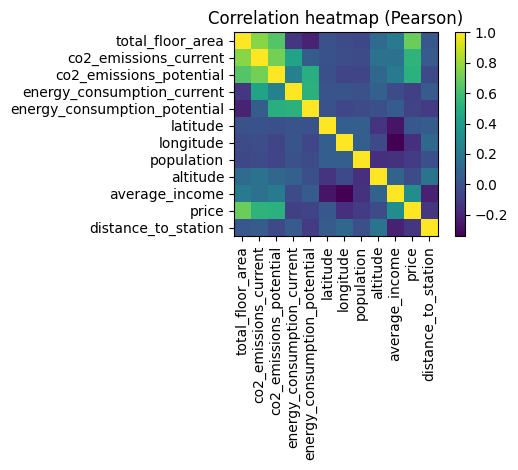

In [22]:
# Converted from R chunk: correlation table
# Compute Pearson correlations for numeric columns (drop non-numeric and ID if present)
df_corr = london_house_prices_2019_training.copy()

if "ID" in df_corr.columns:
    df_corr = df_corr.drop(columns=["ID"])

num_cols = df_corr.select_dtypes(include=[np.number]).columns
corr = df_corr[num_cols].corr(method="pearson")

# Heatmap using matplotlib (no seaborn)
plt.figure()
im = plt.imshow(corr.values, interpolation="nearest")
plt.xticks(range(len(num_cols)), num_cols, rotation=90)
plt.yticks(range(len(num_cols)), num_cols)
plt.title("Correlation heatmap (Pearson)")
plt.colorbar(im, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()


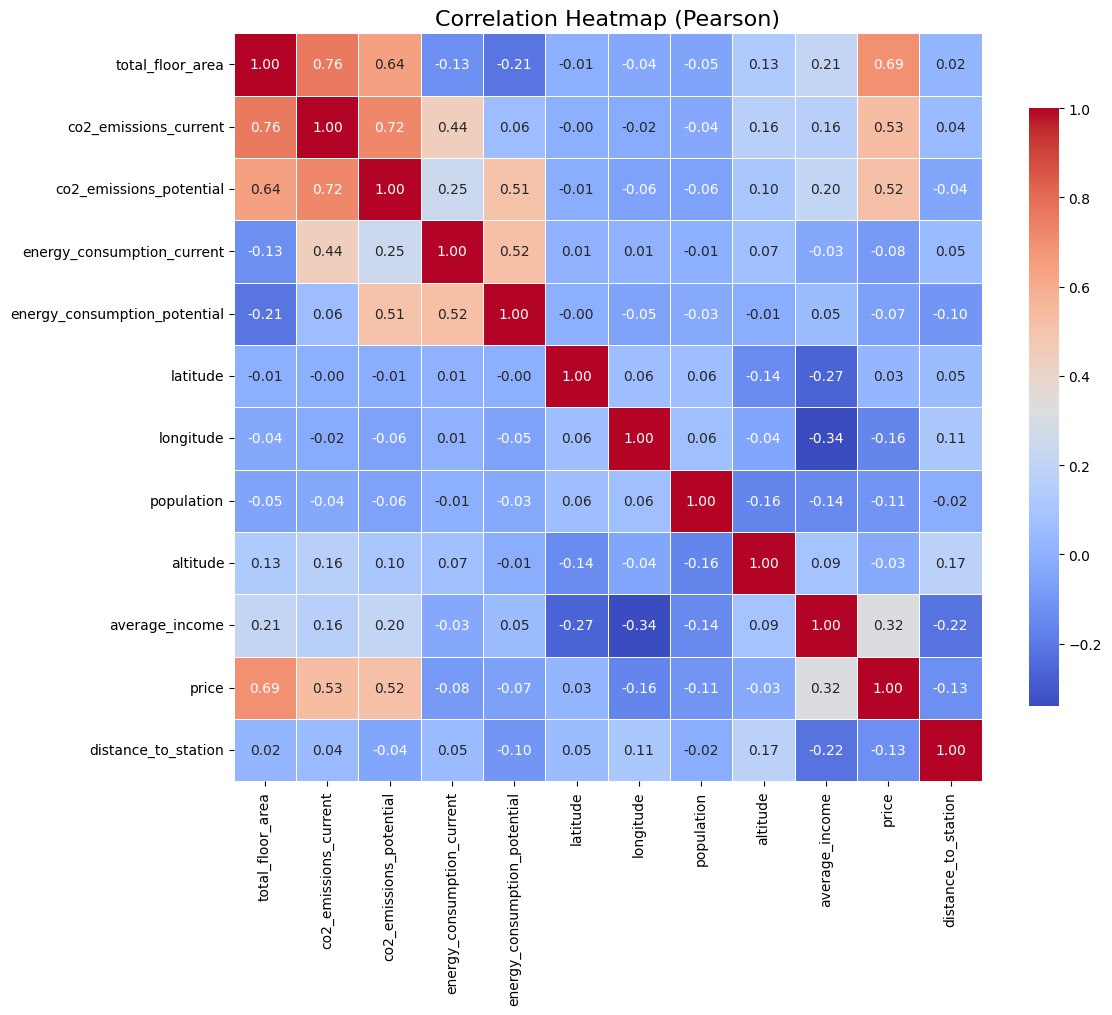

In [23]:
# Plot seaborn correlation heatmap for better visualisation
plt.figure(figsize=(12,10))
sns.heatmap(
    corr, 
    annot=True, 
    fmt=".2f", 
    cmap="coolwarm", 
    cbar_kws={"shrink": 0.8},
    square=True,
    linewidths=0.5
)
plt.title("Correlation Heatmap (Pearson)", fontsize=16)
plt.tight_layout()
plt.show()

# Total floor area has high correlations with the co2 metrics thus indicating potential multicolinearity. Floor area also has a moderate 
# correlation with annual income and energy consumption potential. It is worth considering combining these variables or dropping some. Since total
# floor are has the strongest correlation with price it will likely be used to represent the predictive power of these other variables
# Distance to station and longitude have a moderate correlation with price thus could have influential predictive power too. 




# (Given) Fit a linear regression model

To help you get started I build a linear regression model below. I chose a subset of the features with no particular goal. You can (and should) add more variables and/or choose variable selection methods if you want.



In [24]:
# Converted from R chunk: LR model
# We'll build a scikit-learn Pipeline with preprocessing + LinearRegression
numeric_features = ["distance_to_station", "latitude", "longitude"]
categorical_features = ["water_company", "property_type", "whether_old_or_new", "freehold_or_leasehold"]

preprocess = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
    ],
    remainder="drop",
)

lm_pipe = Pipeline(steps=[
    ("preprocess", preprocess),
    ("regressor", LinearRegression())
])

# 5-fold CV (equivalent to caret::trainControl(method='cv', number=5))
cv = KFold(n_splits=5, shuffle=True, random_state=42)
cv_rmse = (-1 * cross_val_score(lm_pipe, X_train, y_train, cv=cv, scoring="neg_root_mean_squared_error")).mean()
cv_r2 = cross_val_score(lm_pipe, X_train, y_train, cv=cv, scoring="r2").mean()
print(f"Linear Regression 5-fold CV -> RMSE: {cv_rmse:.4f}, R^2: {cv_r2:.4f}")

# Fit on full training set to get a final model (caret refits on all training data)
lm_pipe.fit(X_train, y_train)


Linear Regression 5-fold CV -> RMSE: 485284.9143, R^2: 0.1747


,steps,"[('preprocess', ...), ('regressor', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


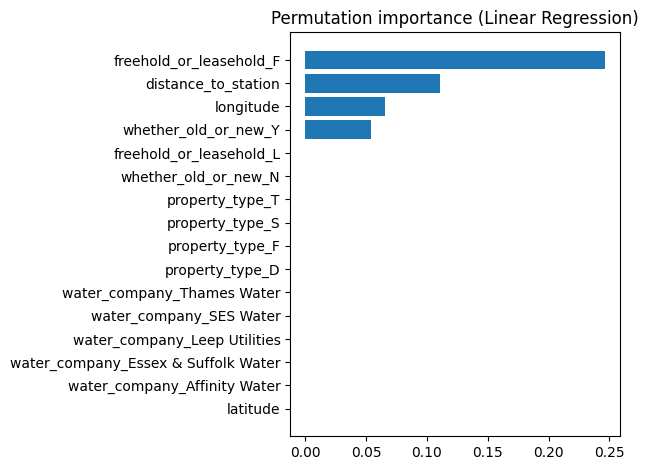

In [25]:
# Converted from R chunk: variable importance for linear model
# We'll use permutation importance on the hold-out set
r = permutation_importance(lm_pipe, X_val, y_val, n_repeats=10, random_state=42)
# Retrieve feature names after preprocessing
ohe = lm_pipe.named_steps["preprocess"].named_transformers_["cat"]
num_names = ["distance_to_station", "latitude", "longitude"]
cat_names = list(ohe.get_feature_names_out(["water_company", "property_type", "whether_old_or_new", "freehold_or_leasehold"]))
feature_names = num_names + cat_names

importances = r.importances_mean
importances = importances[:len(feature_names)]
# Basic bar plot
plt.figure()
order = np.argsort(importances)
plt.barh(np.array(feature_names)[order], importances[order])
plt.title("Permutation importance (Linear Regression)")
plt.tight_layout()
plt.show()


In [26]:
# print(len(feature_names))
# print(len(importances))



## Predict the values in testing and out of sample data

### Below I use the predict function to test the performance of the model in testing data and summarize the performance of the linear regression model. How can you measure the quality of your predictions?



In [27]:
# Converted from R chunk: predictions for linear model
# Predict on the validation split
predictions = lm_pipe.predict(X_val)
rmse = np.sqrt(mean_squared_error(y_val, predictions))
r2 = r2_score(y_val, predictions)
lr_results = {"RMSE": rmse, "Rsquare": r2}
print("lr_results:", lr_results)

# Predict on out-of-sample as well
X_oos = london_house_prices_2019_out_of_sample[["distance_to_station","water_company","property_type","whether_old_or_new","freehold_or_leasehold","latitude","longitude"]]
predictions_oos = lm_pipe.predict(X_oos)


lr_results: {'RMSE': np.float64(422959.391321464), 'Rsquare': 0.1921114989934778}


## Measuring the quality of predictions

*The business objective is to pick the top 200 houses that will maximise investment return. Since housing asset values vary substantially, the quality of a model must be judged by portfolio-level profitability, while extreme outliers should be excluded to control downside risk.*

*The baseline validation must be the statistical model performance on held-out (testing and validation) datasets. The RMSE and R^2 metrics ensure predictive reliability and guards against overfitting. A low RMSE indicates that predicted prices are, on average, closer to observed market prices; R^2 values of ~0.8 indicate strong predictive power while regularising to balance model simplicity and accuracy. Consistent performance across both training and validation sets indicate that a model generalises well and is not overfitted.*

*For investors, predictive accuracy must be translated to the average ROI of the portfolio. I will calculate the expected profit margins of each property thusly: (predicted price -- asking price)/asking price. Next, I will manage risk by excluding properties with extreme residuals or unusually high prediction variance; this reduces exposure to riskier investments. Further, a minimum profit threshold will centre focus on properties with meaningful investment potential.*

*Finally, I will create a summary table comparing each model on the following performance metrics: Train RMSE, Train R2, Validation RMSE, Validation R2, Overfit gap, Average profit %, Top 200 profit%.*

*Having compared models, I will select the model with the smallest overfit gap and a lucrative Top 200 profit*

# (Effie) Linear Regression Model

In [28]:
# print(df_corr.dtypes)

In [29]:
# Converted from R chunk: LR model
# We'll build a scikit-learn Pipeline with preprocessing + LinearRegression
numeric_features_all = ["distance_to_station", "latitude", "longitude", "average_income", "altitude",
                        "energy_consumption_potential", "energy_consumption_current", "co2_emissions_potential", 
                        "co2_emissions_current", "total_floor_area", "population"]
categorical_features_all = ["water_company", "property_type", "whether_old_or_new", "freehold_or_leasehold",
                            "postcode_short", "current_energy_rating", "number_habitable_rooms", "windows_energy_eff",
                            "tenure", "london_zone", "nearest_station", "district",
                            "type_of_closest_station", "num_tube_lines", "num_rail_lines", "num_light_rail_lines"]

preprocess_all = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features_all),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features_all),
    ],
    remainder="drop",
)

lm_pipe_all = Pipeline(steps=[
    ("preprocess", preprocess_all),
    ("regressor", LinearRegression())
])

# 5-fold CV (equivalent to caret::trainControl(method='cv', number=5))
cv_all = KFold(n_splits=5, shuffle=True, random_state=42)
cv_rmse_all = (-1 * cross_val_score(lm_pipe, X_train, y_train, cv=cv_all, scoring="neg_root_mean_squared_error")).mean()
cv_r2_all = cross_val_score(lm_pipe_all, X_train, y_train, cv=cv_all, scoring="r2").mean()
print(f"Linear Regression 5-fold CV -> RMSE: {cv_rmse_all:.4f}, R^2: {cv_r2_all:.4f}")

# Fit on full training set to get a final model (caret refits on all training data)
lm_pipe_all.fit(X_train, y_train)

# Modelling with all variables dramatically increases the R^2 while rmse remains similar, thus outperforming the given
# model above

Linear Regression 5-fold CV -> RMSE: 485284.9143, R^2: 0.6926


,steps,"[('preprocess', ...), ('regressor', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


## Feature selection: VIF, Lassocv and permutation importance

# VIF on numerical variables

In [30]:
# Get Variance Inflation Factor (VIF) for all variables
from statsmodels.stats.outliers_influence import variance_inflation_factor

X_num = X_train[numeric_features_all].copy()
X_num = X_num.fillna(X_num.mean()) # No missing values but including code to fill any for robustness/scalability

vif_data = pd.DataFrame()
vif_data["feature"] = X_num.columns
vif_data["VIF"] = [variance_inflation_factor(X_num.values, i) for i in range (X_num.shape[1])]
print(vif_data)

# consider dropping average income, energy metrics, co2 metrics and total floor area, or combining with other relavant features

                         feature        VIF
0            distance_to_station   4.004569
1                       latitude  94.661101
2                      longitude   1.657243
3                 average_income  55.881640
4                       altitude   3.254881
5   energy_consumption_potential  29.203499
6     energy_consumption_current  52.051880
7        co2_emissions_potential  34.026423
8          co2_emissions_current  51.722158
9               total_floor_area  36.871001
10                    population   4.856329


### Interaction Variables and LassoCV Feature Selection

In [31]:
# Exploring interaction terms, regularising with Lasso and selecting features

# Import Polynomial Features and LassoCV
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LassoCV

interaction = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("scaler", StandardScaler()),
            ("interact", PolynomialFeatures(degree=2, interaction_only=True, include_bias=False))
        ]), numeric_features_all),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features_all)
    ],
    remainder="drop"
)

# Build full Lasso pipeline
lasso_pipe_interact = Pipeline([
    ('preprocess', interaction),
    ('regressor', LassoCV(cv=5))
])

# fit LassoCV to training data to determine best alpha
lasso_pipe_interact.fit(X_train, y_train)
best_alpha = lasso_pipe_interact.named_steps['regressor'].alpha_
print(f"The best alpha for LassoCV regularisation is {best_alpha:.4f}")

The best alpha for LassoCV regularisation is 847.0258


In [32]:
# Get performance on training set
cv_rmse_int = (
    -1 *cross_val_score(
        lasso_pipe_interact,
        X_train, y_train,
        cv=cv_all,
        scoring="neg_root_mean_squared_error"
    ).mean()
)

cv_r2_int = cross_val_score(
    lasso_pipe_interact,
    X_train, y_train,
    cv=cv_all,
    scoring="r2"
).mean()

print(f"Lasso with interactions on Training \nRMSE: {cv_rmse_int:.4f} \nR^2:{cv_r2_int:.4f}")

Lasso with interactions on Training 
RMSE: 261264.9873 
R^2:0.7606


In [33]:
# Get full feature names
feature_names = (
    lasso_pipe_interact
    .named_steps["preprocess"]
    .get_feature_names_out()
)

coefficients = lasso_pipe_interact.named_steps["regressor"].coef_

important_features = feature_names[coefficients != 0]
important_coefs = coefficients[coefficients != 0]

# Sort by absolute importance
sorted_idx = np.argsort(np.abs(important_coefs))[::-1]

for i in sorted_idx[:20]:
    print(f"{important_features[i]}: {important_coefs[i]:.4f}")


cat__district_Kensington and Chelsea: 598392.0754
cat__london_zone_1: 451893.6210
cat__postcode_short_SW1X: 402949.7618
cat__postcode_short_SW3: 343800.6200
cat__district_Westminster: 276968.6478
cat__postcode_short_W14: -219709.3828
num__total_floor_area: 208780.3747
cat__london_zone_2: 200954.6713
cat__postcode_short_NW3: 139861.9416
cat__london_zone_3: 81471.4868
cat__district_Hammersmith and Fulham: 71209.1610
num__altitude total_floor_area: -61847.9456
num__average_income: 56900.6517
cat__postcode_short_SW6: 49089.0690
cat__district_Camden: 46127.5788
cat__district_Croydon: -45333.0619
num__total_floor_area population: -42129.4640
num__co2_emissions_potential: 41850.3235
num__co2_emissions_current total_floor_area: 40087.9198
cat__water_company_Affinity Water: -36419.5304


### Permutation Importance

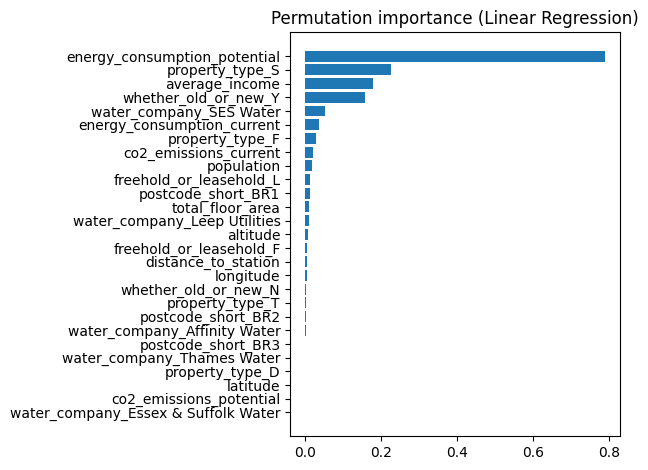

In [34]:
# Permutation importance on validation set
r = permutation_importance(lm_pipe_all, X_val, y_val, n_repeats=10, random_state=42)
# Retrieve feature names after preprocessing
ohe = lm_pipe_all.named_steps["preprocess"].named_transformers_["cat"]
num_names = ["distance_to_station", "latitude", "longitude", "average_income", "altitude",
                        "energy_consumption_potential", "energy_consumption_current", "co2_emissions_potential", 
                        "co2_emissions_current", "total_floor_area", "population"]
cat_names = list(ohe.get_feature_names_out())
feature_names = num_names + cat_names

importances = r.importances_mean
importances = importances[:len(feature_names)]
# Basic bar plot
plt.figure()
order = np.argsort(importances)
plt.barh(np.array(feature_names)[order], importances[order])
plt.title("Permutation importance (Linear Regression)")
plt.tight_layout()
plt.show()

# Variables worth featuring: energy consumption metrics (both, perhaps combined), whether_old_or_new_Y, average income
# postcode_short, propety type, water company, altitude, distance to station, longitude

In [35]:
# I dropped latitude from the numerical features after seeing the high VIF scores and intuiting that its effect can be represented by longitude. 
# I also flagged some variables [average income, energy metrics, co2 metrics and total floor area] that could be dropped after sense checking 
# with lassocv selection

# After interacting variables and regularising with lasso cv, I selected total_floor_area to represent the following variables that I dropped:
# average_income, altitude, co2 metrics and population. For categorical variables I only kept the important ones: postcode_short, london_zone, district

# By sense checking with permutation importance, I dropped current energy and only used potential energy; I readded water_company, property_type,
# whether_old_or_new and freehold_or_leasehold. 

numeric_features_ed = ["distance_to_station", "longitude","energy_consumption_potential",
                    "total_floor_area"]
categorical_features_ed = ["water_company", "property_type", "whether_old_or_new", "freehold_or_leasehold",
                            "postcode_short", "district", "london_zone"]

preprocess_ed = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features_ed), 
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features_ed),
    ],
    remainder="drop",
)

lm_pipe_ed = Pipeline(steps=[
    ("preprocess", preprocess_ed),
    ("regressor", LinearRegression())
])

# 5-fold CV (equivalent to caret::trainControl(method='cv', number=5))
cv_ed = KFold(n_splits=5, shuffle=True, random_state=42)
cv_rmse_ed = (-1 * cross_val_score(lm_pipe, X_train, y_train, cv=cv_ed, scoring="neg_root_mean_squared_error")).mean()
cv_r2_ed = cross_val_score(lm_pipe_all, X_train, y_train, cv=cv_ed, scoring="r2").mean()
print(f"Linear Regression 5-fold CV -> RMSE: {cv_rmse_ed:.4f}, R^2: {cv_r2_ed:.4f}")

# Fit on full training set to get a final model (caret refits on all training data)
lm_pipe_ed.fit(X_train, y_train)

# Modelling with all variables dramatically increases the R^2 while rmse remains similar, thus outperforming the given
# model above

Linear Regression 5-fold CV -> RMSE: 485284.9143, R^2: 0.6926


,steps,"[('preprocess', ...), ('regressor', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [36]:
# Get RMSE and R2 from Linear LassoCV on Validation set
y_val_lm = lm_pipe_ed.predict(X_val)

rmse_lm_val = np.sqrt(mean_squared_error(y_val, y_val_lm))
r2_lm_val = r2_score(y_val, y_val_lm)

print("Linear Regression (validation)")
print(f"RMSE: {rmse_lm_val:.4f}")
print(f"R²:   {r2_lm_val:.4f}")

Linear Regression (validation)
RMSE: 252778.7862
R²:   0.7114


In [37]:
# large drop in RMSE with interactions therefore:
# Exploring interaction terms, regularising with elastic net cross-validation for more reliable interaction selection

#from sklearn.linear_model import ElasticNetCV, ElasticNet
#from sklearn.pipeline import Pipeline
#from sklearn.model_selection import cross_val_score, KFold

# Fit ElasticNetCV once to find best hyperparameters
#enet_cv = ElasticNetCV(cv=5, n_jobs=-1)  # use n_jobs=-1 for speed
#enet_pipe = Pipeline([
 #   ('preprocess', interaction), # use interaction from lasso
 #   ('regressor', enet_cv)
#])
#enet_pipe.fit(X_train, y_train)

# Extract best parameters
#best_alpha = enet_cv.alpha_
#best_l1_ratio = enet_cv.l1_ratio_

In [38]:
# Build a pipeline with ElasticNet using those parameters
# enet_fixed_pipe = Pipeline([
    #('preprocess', interaction),
    #('regressor', ElasticNet(alpha=best_alpha, l1_ratio=best_l1_ratio, max_iter=10000))
#])

# Cross-validate RMSE and R2
#cv_outer = KFold(n_splits=5, shuffle=True, random_state=42)
#cv_rmse_en = -cross_val_score(
    #enet_fixed_pipe, X_train, y_train,
    #cv=cv_outer, scoring="neg_root_mean_squared_error", n_jobs=-1
#).mean()
#cv_r2_en = cross_val_score(
    #enet_fixed_pipe, X_train, y_train,
    #cv=cv_outer, scoring="r2", n_jobs=-1
#).mean()

#print(f"ElasticNet (train CV)\nRMSE: {cv_rmse_en:.4f}\nR²: {cv_r2_en:.4f}")

*The computation time for ElasticNetCV was taking too long, so I deprioritised further, robust feature selection for my linear regression model. Instead, the next viable solution is to use ridge; no feature selection but meets requirements of increased robustness and reduced variance*

In [39]:
# Import ridge CV

from sklearn.linear_model import RidgeCV

# Use selected features and interaction variables for regularisation with RidgeCV to get more robust linear model
interaction2 = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("scaler", StandardScaler()),
            ("interact", PolynomialFeatures(degree=2, interaction_only=True, include_bias=False))
        ]), numeric_features_ed),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features_ed)
    ],
    remainder="drop"
)

# Create ridge pipeline
ridge_pipe = Pipeline([
    ("preprocess", interaction2),
    ("regressor", RidgeCV(
        alphas=np.logspace(-4, 3, 50),
        cv=5
    ))
])

# Cross validate and get performance on training
cv = KFold(n_splits=5, shuffle=True, random_state=42)

ridge_rmse = (
    -cross_val_score(
        ridge_pipe,
        X_train, y_train,
        cv=cv,
        scoring="neg_root_mean_squared_error"
    ).mean()
)

ridge_r2 = cross_val_score(
    ridge_pipe,
    X_train, y_train,
    cv=cv,
    scoring="r2"
).mean()

print("\nRidge (train CV)")
print(f"RMSE: {ridge_rmse:.4f}")
print(f"R²:   {ridge_r2:.4f}")


Ridge (train CV)
RMSE: 272604.8171
R²:   0.7396


In [40]:
# Fit ridge to full model

ridge_pipe.fit(X_train, y_train)
ridge = ridge_pipe.named_steps["regressor"]
ridge_alpha = ridge.alpha_

print("Selected alpha for ridge:", ridge_alpha)


Selected alpha for ridge: 1.389495494373136


In [41]:
# Get ridge performance on validation set

y_val_ridge = ridge_pipe.predict(X_val)

ridge_rmse_val = np.sqrt(mean_squared_error(y_val, y_val_ridge))
r2_ridge_val = r2_score(y_val, y_val_ridge)

print("\nRidge (validation)")
print(f"RMSE: {ridge_rmse_val:.4f}")
print(f"R²:   {r2_ridge_val:.4f}")



Ridge (validation)
RMSE: 247938.9275
R²:   0.7224




# Fit a tree model

Next I fit a tree model using the same subset of features. Again you can (and should) add more variables and tune the parameter of your tree to find a better fit. 

Compare the performance of the linear regression model with the tree model; which one performs better? Why do you think that is the case?



In [42]:
# Converted from R chunk: LR model
# We'll build a scikit-learn Pipeline with preprocessing + LinearRegression
numeric_features = ["distance_to_station", "latitude", "longitude"]
categorical_features = ["water_company", "property_type", "whether_old_or_new", "freehold_or_leasehold"]

# change from linear model to decision tree
preprocess_dt = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
    ],
    remainder="drop",
)

dt_pipe = Pipeline(steps=[
    ("preprocess", preprocess_dt),
    ("regressor", DecisionTreeRegressor())
])

# 5-fold CV (equivalent to caret::trainControl(method='cv', number=5))
cv_dt = KFold(n_splits=5, shuffle=True, random_state=42)
cv_rmse_dt = (-1 * cross_val_score(dt_pipe, X_train, y_train, cv=cv_dt, scoring="neg_root_mean_squared_error")).mean()
cv_r2_dt = cross_val_score(dt_pipe, X_train, y_train, cv=cv_dt, scoring="r2").mean()
print(f"Decision Tree 5-fold CV -> RMSE: {cv_rmse_dt:.4f}, R^2: {cv_r2_dt:.4f}")

# Fit on full training set to get a final model (caret refits on all training data)
dt_pipe.fit(X_train, y_train)


Decision Tree 5-fold CV -> RMSE: 456436.0249, R^2: 0.2669


,steps,"[('preprocess', ...), ('regressor', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [43]:
# Create decision tree with selected features
preprocess_dt2 = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features_ed),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features_ed),
    ],
    remainder="drop",
)

dt_pipe2 = Pipeline(steps=[
    ("preprocess", preprocess_dt2),
    ("regressor", DecisionTreeRegressor())
])

# Tune parameters using GridSearchCV
param_grid2 = {
    "regressor__max_depth": [3, 5, 7, 10, None],
    "regressor__min_samples_split": [2, 5, 10],
    "regressor__min_samples_leaf": [1, 2, 4]
}
grid_search = GridSearchCV(dt_pipe2, param_grid2, cv=5, scoring="neg_root_mean_squared_error", n_jobs=-1)
grid_search.fit(X_train, y_train)
best_dt_pipe2 = grid_search.best_estimator_
best_dt2_params = grid_search.best_params_
print("Best hyperparameters for Decision Tree:")
print(grid_search.best_params_)

# 5-fold CV (equivalent to caret::trainControl(method='cv', number=5))
cv_dt2 = KFold(n_splits=5, shuffle=True, random_state=42)
cv_rmse_dt2 = (-1 * cross_val_score(best_dt_pipe2, X_train, y_train, cv=cv_dt2, scoring="neg_root_mean_squared_error")).mean()
cv_r2_dt2 = cross_val_score(best_dt_pipe2, X_train, y_train, cv=cv_dt2, scoring="r2").mean()
print('='*60)
print(f"Decision Tree 5-fold CV on Training -> RMSE: {cv_rmse_dt2:.4f}, R^2: {cv_r2_dt2:.4f}")

# Fit on full training set to get a final model (caret refits on all training data)
best_dt_pipe2.fit(X_train, y_train)

# Predict on validation set
predictions_dt2 = best_dt_pipe2.predict(X_val)
mse_dt2 = mean_squared_error(y_val, predictions_dt2)
rmse_dt2 = np.sqrt(mse_dt2)
r2_dt2 = r2_score(y_val, predictions_dt2)
dt_results2 = {"RMSE": rmse_dt2, "Rsquare": r2_dt2}
dt2_results_df = pd.DataFrame([dt_results2])
print('='*60)
print("Decision Tree Results on Validation:")
print(dt2_results_df)

Best hyperparameters for Decision Tree:
{'regressor__max_depth': 10, 'regressor__min_samples_leaf': 1, 'regressor__min_samples_split': 10}
Decision Tree 5-fold CV on Training -> RMSE: 257842.8254, R^2: 0.7651
Decision Tree Results on Validation:
           RMSE   Rsquare
0  238743.03124  0.742596





# Other algorithms

Use at least two other algorithms to predict prices. Don't forget to tune the parameters of these algorithms. And then compare the performances of your algorithms to linear regression and trees.




## Gradient Boosting Model

In [44]:
# Predict prices using gradient boosting model

from sklearn.ensemble import GradientBoostingRegressor

# We'll build a scikit-learn Pipeline with preprocessing + GradientBoostingRegressor
gb_pipe = Pipeline(steps=[
    ("preprocess", preprocess_ed), #reuse preprocessing from linear model with added features
    ("regressor", GradientBoostingRegressor(random_state=42))
])

# Tune parameters using GridSearchCV
param_grid_gb = {
    "regressor__n_estimators": [100, 200],
    "regressor__learning_rate": [0.05, 0.1],
    "regressor__max_depth": [3, 5],
    "regressor__min_samples_split": [2, 5],
    "regressor__min_samples_leaf": [1, 2]
}   
grid_search_gb = GridSearchCV(gb_pipe, param_grid_gb, cv=5, scoring="neg_root_mean_squared_error", n_jobs=-1)
grid_search_gb.fit(X_train, y_train)
best_gb_pipe = grid_search_gb.best_estimator_
best_gb_params = grid_search_gb.best_params_
print("Best hyperparameters for Gradient Boosting:")
print(best_gb_params)

# 5-fold CV for the best gradient boosting model
cv_gb = KFold(n_splits=5, shuffle=True, random_state=42)
cv_rmse_gb_best = (-1 * cross_val_score(best_gb_pipe, X_train, y_train, cv=cv_gb, scoring="neg_root_mean_squared_error")).mean()
cv_r2_gb_best = cross_val_score(best_gb_pipe, X_train, y_train, cv=cv_gb, scoring="r2").mean()
print(f"\nGradient Boosting 5-fold CV on Training -> RMSE: {cv_rmse_gb_best:.4f}, R^2: {cv_r2_gb_best:.4f}")

Best hyperparameters for Gradient Boosting:
{'regressor__learning_rate': 0.1, 'regressor__max_depth': 3, 'regressor__min_samples_leaf': 2, 'regressor__min_samples_split': 5, 'regressor__n_estimators': 200}

Gradient Boosting 5-fold CV on Training -> RMSE: 213333.7687, R^2: 0.8405


In [45]:
# Fit tuned gb on full training set to get a final model (caret refits on all training data)
best_gb_pipe.fit(X_train, y_train)

# Predict on the validation split
predictions_gb = best_gb_pipe.predict(X_val)
mse_gb = mean_squared_error(y_val, predictions_gb)
rmse_gb = np.sqrt(mse_gb)
r2_gb = r2_score(y_val, predictions_gb)
gb_results = {"RMSE": rmse_gb, "Rsquare": r2_gb}
gb_results_df = pd.DataFrame([gb_results])
print("\nGradient Boosting on Validation Results:")
print(gb_results_df)    


Gradient Boosting on Validation Results:
            RMSE   Rsquare
0  186091.524299  0.843611


## Random Forest Model


In [46]:
# Predict prices using random forest model
from sklearn.ensemble import RandomForestRegressor  

# We'll build a scikit-learn Pipeline with preprocessing + RandomForestRegressor
rf_pipe = Pipeline(steps=[
    ("preprocess", preprocess_ed), #reuse preprocessing from linear model with added features
    ("regressor", RandomForestRegressor(random_state=42))
])

# Tune parameters using GridSearchCV
param_grid_rf = {
    "regressor__n_estimators": [100, 200],
    "regressor__max_depth": [10, 20, None],
    "regressor__min_samples_split": [2, 5],
    "regressor__min_samples_leaf": [1, 2]
}
grid_search_rf = GridSearchCV(rf_pipe, param_grid_rf, cv=5, scoring="neg_root_mean_squared_error", n_jobs=-1)
grid_search_rf.fit(X_train, y_train)
best_rf_pipe = grid_search_rf.best_estimator_
best_rf_params = grid_search_rf.best_params_
print("Best hyperparameters for Random Forest:")
print(best_rf_params)

# 5-fold CV for the best random forest model
cv_rf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_rmse_rf_best = (-1 * cross_val_score(best_rf_pipe, X_train, y_train, cv=cv_rf, scoring="neg_root_mean_squared_error")).mean()
cv_r2_rf_best = cross_val_score(best_rf_pipe, X_train, y_train, cv=cv_rf, scoring="r2").mean()
print(f"\nRandom Forest 5-fold CV on Training -> RMSE: {cv_rmse_rf_best:.4f}, R^2: {cv_r2_rf_best:.4f}")

Best hyperparameters for Random Forest:
{'regressor__max_depth': None, 'regressor__min_samples_leaf': 1, 'regressor__min_samples_split': 2, 'regressor__n_estimators': 100}

Random Forest 5-fold CV on Training -> RMSE: 215089.0483, R^2: 0.8371


In [47]:
# Fit tuned rf model on full training set to get a final model (caret refits on all training data)
best_rf_pipe.fit(X_train, y_train)

# Predict on the validation split
predictions_rf = best_rf_pipe.predict(X_val)
mse_rf = mean_squared_error(y_val, predictions_rf)
rmse_rf = np.sqrt(mse_rf)
r2_rf = r2_score(y_val, predictions_rf)
rf_results = {"RMSE": rmse_rf, "Rsquare": r2_rf}
rf_results_df = pd.DataFrame([rf_results])
print("\nRandom Forest on Validation Results:")
print(rf_results_df)


Random Forest on Validation Results:
            RMSE   Rsquare
0  199857.068215  0.819618


## XGBoost

In [48]:
# Predict prices using XGBoost model

# Import XGBoost
import xgboost
from xgboost import XGBRegressor
from sklearn.model_selection import KFold, RandomizedSearchCV

# Build a scikit-learn Pipeline with preprocessing + XGBRegressor
xgb_pipe = Pipeline(steps=[
    ("preprocess", preprocess_ed), #reuse preprocessing from linear model with selected features
    ("regressor", XGBRegressor(random_state=42, objective='reg:squarederror'))
]) 

# Choose hyperparameter search space to balance performance and runtime
param_dist = {
    "regressor__n_estimators": [200, 400, 600],
    "regressor__learning_rate": [0.01, 0.05, 0.1],
    "regressor__max_depth": [3, 4, 5, 6],
    "regressor__min_child_weight": [1, 5, 10],
    "regressor__subsample": [0.7, 0.8, 1.0],
    "regressor__colsample_bytree": [0.7, 0.8, 1.0],
    "regressor__gamma": [0, 0.1, 0.3]
}

# Tune parameters using RandomisedCV
cv_xg = KFold(n_splits=5, shuffle=True, random_state=42)

xgb_search = RandomizedSearchCV(
    estimator=xgb_pipe,
    param_distributions=param_dist,
    n_iter=40,                        # good trade-off
    scoring="neg_root_mean_squared_error",
    cv=cv_xg,
    verbose=1,
    n_jobs=-1,
    random_state=42
)

xgb_search.fit(X_train, y_train)

# Get optimal tuning parameters for stacking later
print("Best CV RMSE:", -xgb_search.best_score_)
print("Best parameters for XGBoost:")
for k, v in xgb_search.best_params_.items():
    print(f"{k}: {v}")
# Store best parameters as DataFrame
xgb_best_params = pd.DataFrame([xgb_search.best_params_])

# CV performance of tuned XGBoost
best_xgb_pipe = xgb_search.best_estimator_

# 5-fold CV (equivalent to caret::trainControl(method='cv', number=5))
cv_xg = KFold(n_splits=5, shuffle=True, random_state=42)
cv_rmse_xgb = (-1 * cross_val_score(best_xgb_pipe, X_train, y_train, cv=cv_xg, scoring="neg_root_mean_squared_error")).mean()
cv_xgb_r2 = cross_val_score(best_xgb_pipe, X_train, y_train, cv=cv_xg, scoring="r2").mean()
print(f"\nXGBoost 5-fold CV on Training -> RMSE: {cv_rmse_xgb:.4f}, R^2: {cv_xgb_r2:.4f}")

Fitting 5 folds for each of 40 candidates, totalling 200 fits
Best CV RMSE: 202873.8951348862
Best parameters for XGBoost:
regressor__subsample: 1.0
regressor__n_estimators: 600
regressor__min_child_weight: 5
regressor__max_depth: 4
regressor__learning_rate: 0.1
regressor__gamma: 0.1
regressor__colsample_bytree: 0.8

XGBoost 5-fold CV on Training -> RMSE: 202873.8951, R^2: 0.8556


In [49]:
# Fit on full training set to get a final model (caret refits on all training data)
best_xgb_pipe.fit(X_train, y_train)

# Predict on the validation split
predictions_xgb = best_xgb_pipe.predict(X_val)
mse_xgb = mean_squared_error(y_val, predictions_xgb)
rmse_xgb = np.sqrt(mse_xgb)
r2_xgb = r2_score(y_val, predictions_xgb)
xgb_results = {"RMSE": rmse_xgb, "Rsquare": r2_xgb}
xgb_results_df = pd.DataFrame([xgb_results])
print("\nXGBoost on Validation Results:")
print(xgb_results_df)


XGBoost on Validation Results:
           RMSE   Rsquare
0  195970.82955  0.826565


# Stacking

Use stacking to ensemble your algorithms.

In [50]:
# Converted from R chunk: (use at least two other algorithms)
# The original R chunk was intentionally left blank for students to implement.
# Here are placeholders you can fill with, e.g., RandomForestRegressor, GradientBoostingRegressor, XGBRegressor, etc.
# Example skeleton:
# from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
# rf_pipe = Pipeline([... , ("regressor", RandomForestRegressor(random_state=42))])
# gb_pipe = Pipeline([... , ("regressor", GradientBoostingRegressor(random_state=42))])
# Fit, cross-validate, compare RMSE/R2 with lm_pipe and model2_tree.


In [51]:
# Gather tuned hyperparameters for each model"
print ("="*60)
print ("OPTIMISED HYPERPARAMETERS FOR EACH MODEL")
print ("="*60)

print(f"\nRidge Selected Alpha:{ridge_alpha}")
print(f"\nDecision Tree Best Hyperparameters:{best_dt2_params}")
print(f"\nGradient Boosting Best Hyperparameters:{best_gb_params}")
print(f"\nRandom Forest Best Hyperparameters:{best_rf_params}")
print(f"\nXGBoost Best Hyperparameters:{xgb_best_params}")

OPTIMISED HYPERPARAMETERS FOR EACH MODEL

Ridge Selected Alpha:1.389495494373136

Decision Tree Best Hyperparameters:{'regressor__max_depth': 10, 'regressor__min_samples_leaf': 1, 'regressor__min_samples_split': 10}

Gradient Boosting Best Hyperparameters:{'regressor__learning_rate': 0.1, 'regressor__max_depth': 3, 'regressor__min_samples_leaf': 2, 'regressor__min_samples_split': 5, 'regressor__n_estimators': 200}

Random Forest Best Hyperparameters:{'regressor__max_depth': None, 'regressor__min_samples_leaf': 1, 'regressor__min_samples_split': 2, 'regressor__n_estimators': 100}

XGBoost Best Hyperparameters:   regressor__subsample  regressor__n_estimators  regressor__min_child_weight  regressor__max_depth  \
0                   1.0                      600                            5                     4   

   regressor__learning_rate  regressor__gamma  regressor__colsample_bytree  
0                       0.1               0.1                          0.8  


In [52]:
# Imports for stacking
from sklearn.linear_model import LinearRegression, Lasso, Ridge, ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, StackingRegressor
from xgboost import XGBRegressor

# Using one preprocessor to avoid data leakage and inconsistency
preprocess_stack = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("scaler", StandardScaler()),
            ("interact", PolynomialFeatures(
                degree=2,
                interaction_only=True,
                include_bias=False
            ))
        ]), numeric_features_ed),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features_ed)
    ],
    remainder="drop"
)

# Gather base models for stack
base_models = [
    ("lr", LinearRegression()), 
    ("ridge", Ridge(alpha=1.389495494373136)),   # use best hyperparameters from earlier tuning
    ("dt", DecisionTreeRegressor(
        max_depth=10,
        min_samples_leaf=1,
        random_state=10
    )),
    ("rf", RandomForestRegressor(     # use best hyperparameters from earlier tuning
        n_estimators=100,
        max_depth=None,
        min_samples_leaf=1,
        min_samples_split= 2,
        n_jobs=-1,
        random_state=42
    )),
    ("gb", GradientBoostingRegressor( # use best hyperparameters from earlier tuning
        n_estimators=200,
        learning_rate=0.1,
        max_depth=3,
        min_samples_leaf=2,
        min_samples_split=5,
        random_state=42
    )),
    ("xgb", XGBRegressor(             # use best hyperparameters from earlier tuning
        n_estimators=600,
        learning_rate=0.1,
        max_depth=4,
        subsample=1.0,
        colsample_bytree=0.8,
        min_child_weight=5,
        gamma=0.1,
        objective="reg:squarederror",
        n_jobs=-1,
        random_state=42
    ))
]

In [53]:
# Use elastic net to automatically weigh base models and prevent overfitting
meta_model = ElasticNet(
    alpha=0.01,
    l1_ratio=0.7,
    max_iter=10000,
    random_state=42
)

# Stack using out-of-fold predictions
stacked_model = StackingRegressor(
    estimators=base_models,
    final_estimator=meta_model,
    cv=5,
    n_jobs=-1,
    passthrough=False
)

# Create full pipline
stack_pipe = Pipeline([
    ("preprocess", preprocess_stack),
    ("stack", stacked_model)
])

# Assess performance on cross-validated training data
cv = KFold(n_splits=5, shuffle=True, random_state=42)

cv_rmse = (
    -cross_val_score(
        stack_pipe,
        X_train, y_train,
        cv=cv,
        scoring="neg_root_mean_squared_error"
    ).mean()
)

cv_r2 = cross_val_score(
    stack_pipe,
    X_train, y_train,
    cv=cv,
    scoring="r2"
).mean()

print("Stacked model (train CV)")
print(f"RMSE: {cv_rmse:.4f}")
print(f"R²:   {cv_r2:.4f}")


Stacked model (train CV)
RMSE: 198832.6509
R²:   0.8613


In [54]:
# Fit final stacked model
stack_pipe.fit(X_train, y_train)

# Assess performance on validation set
y_val_stack = stack_pipe.predict(X_val)

val_rmse_stack = np.sqrt(mean_squared_error(y_val, y_val_stack))
val_r2_stack = r2_score(y_val, y_val_stack)

print("\nStacked model (validation)")
print(f"RMSE: {val_rmse_stack:.4f}")
print(f"R²:   {val_r2_stack:.4f}")



Stacked model (validation)
RMSE: 185181.9274
R²:   0.8451


In [55]:
# Assess the contributions of each model
meta_coefs = stack_pipe.named_steps["stack"].final_estimator_.coef_

for name, coef in zip([m[0] for m in base_models], meta_coefs):
    print(f"{name}: {coef:.4f}")


lr: 1.4601
ridge: -1.4675
dt: 0.0118
rf: -0.0272
gb: 0.3259
xgb: 0.7151


# Comparing predictions

In [56]:
# Compare models based on train vs. test rmse and r2, overfitting gap, avg. profit%, top 200 profit%

models = {                                      # Create dictionary of models, to compare the linear models and DT with
    "Linear Reg": lm_pipe_ed,                       # the others 
    "RidgeCV Reg": ridge_pipe,
    "Decision Tree": best_dt_pipe2,
    "Gradient Boosting": best_gb_pipe,
    "Random Forest": best_rf_pipe,
    "XGBoost": best_xgb_pipe,
    "Stacking": stack_pipe
}

# Define profit margin
def profit_margin(y_true, y_pred):
    return (y_pred - y_true) / y_true

# Exclude extreme residuals and predictions with low profit margin
def property_filter(
        y_true,
        y_pred,
        min_profit=0.05,
        residual_quantile=0.95
):
    residuals=np.abs(y_pred - y_true)
    res_cutoff = np.quantile(residuals, residual_quantile)

    margins = profit_margin(y_true, y_pred)

    mask = (
        (residuals <= res_cutoff) &
        (margins >= min_profit)
    )

    return margins[mask]


# Create model comparison loop
results = []
cv = KFold(n_splits=5, shuffle=True, random_state=42)
for name, model in models.items():

    train_rmse = (-cross_val_score(         # train cv metrics
        model, X_train, y_train, cv=cv, scoring="neg_root_mean_squared_error"
    )).mean()
    train_r2 = cross_val_score(
        model, X_train, y_train, cv=cv, scoring="r2"
    ).mean()

    model.fit(X_train, y_train)             # Fit model

    y_val_pred = model.predict(X_val)       # Validation predictions      
    val_rmse = np.sqrt(mean_squared_error(y_val, y_val_pred))
    val_r2 = r2_score(y_val, y_val_pred)

    margins_all = profit_margin(y_val, y_val_pred)

    mean_margin = np.mean(margins_all)      # Get mean to meet the business objective
    median_margin = np.median(margins_all)  # Median is a measure of robustness

    margins_filtered = property_filter(     # Filter out properties with extreme residuals and low profit margins
        y_val, y_val_pred,
        min_profit=0.05,
        residual_quantile=0.95
    )

    top_200 = np.sort(margins_filtered)[-200:] # sorts top 200 properties for ROI!

    results.append({                            # compile everthing into one list
        "Model": name,
        "Train RMSE": train_rmse,
        "Train R2": train_r2,
        "Val RMSE": val_rmse,
        "Val R2": val_r2,
        "Overfitting Gap": train_r2 - val_r2,
        "Mean Profit % (Val)": mean_margin*100,
        "Median Profit % (Val)": median_margin*100,
        "Mean Profit % (Val Top 200)": np.mean(top_200)*100,
        "Median Profit % (Val Top 200)": np.median(top_200)*100
    })

# Transform comparison metrics into a dataframe to view as a table
results_df = pd.DataFrame(results)
results_df = results_df.sort_values(
    by="Mean Profit % (Val Top 200)", 
    ascending=False
)

# Make table more readable
results_df = results_df.round({
    "Train RMSE": 3,
    "Train R2": 3,
    "Val RMSE": 3,
    "Val R2": 3,
    "Overfitting Gap": 3,
    "Mean Profit % (Val)": 2,
    "Median Profit % (Val)": 2,
    "Mean Profit % (Top 200)": 2,
    "Median Profit % (Top 200)": 2
})

results_df

,Model,Train RMSE,Train R2,Val RMSE,Val R2,Overfitting Gap,Mean Profit % (Val),Median Profit % (Val),Mean Profit % (Val Top 200),Median Profit % (Val Top 200)
2,Decision Tree,259394.869,0.764,238425.685,0.743,0.021,6.28,1.62,82.334043,67.572879
0,Linear Reg,282384.014,0.721,252778.786,0.711,0.009,1.40,-1.66,73.900035,62.883367
3,Gradient Boosting,213333.769,0.840,186091.524,0.844,-0.003,5.78,1.47,71.727868,56.814791
4,Random Forest,215089.048,0.837,199857.068,0.820,0.017,4.93,0.71,69.971883,54.603254
1,RidgeCV Reg,272604.817,0.740,247938.927,0.722,0.017,1.56,-1.94,69.451357,59.532380
5,XGBoost,202873.895,0.856,195970.830,0.827,0.029,4.53,0.35,66.463561,52.125174
6,Stacking,198832.651,0.861,185181.927,0.845,0.016,4.35,0.63,66.355422,51.306876





# Pick investments

In this section you should use the best algorithm you identified to choose 200 properties from the out of sample data.



In [57]:
# Converted from R chunk: Pick investments & create submission
# numchoose = 200

# Predict value of houses on OOS using the decision tree pipeline
# X_oos = london_house_prices_2019_out_of_sample[["distance_to_station","water_company","property_type","whether_old_or_new","freehold_or_leasehold","latitude","longitude"]].copy()
# oos = london_house_prices_2019_out_of_sample.copy()
# oos["predict"] = model2_tree.predict(X_oos)

# Choose the ones you want to invest here
# Make sure you choose exactly 200 of them
# Example placeholder: create a 'buy' column (0/1). Students should implement their own selection logic.
# oos = oos.sort_values(by="predict", ascending=False)
# oos["buy"] = 0
# oos.loc[: numchoose - 1, "buy"] = 1
# assert oos["buy"].sum() == numchoose

# Output your choices. Change the name to your "lastname_firstname.csv"
# oos.to_csv("my_submission.csv", index=False)
# print("Wrote my_submission.csv")


In [58]:
# Choosing investments with the gradient boosting model 
# #yay #we did it #so proud of myself #learned so much

# Predict value of houses on OOS using tuned gradient boosting model
X_oos = london_house_prices_2019_out_of_sample[['distance_to_station', 'longitude', 'energy_consumption_potential',
                                                'total_floor_area', 'water_company', 'property_type', 'whether_old_or_new',
                                                'freehold_or_leasehold', 'postcode_short', 'district', 'london_zone']].copy()
oos = london_house_prices_2019_out_of_sample.copy()
oos["predicted_price"] = best_gb_pipe.predict(X_oos)

In [59]:
# print(oos["asking_price"]).head()

In [60]:
# Compute expected profit
oos["expected_profit"] = (
    oos["predicted_price"] - oos["asking_price"]
)/oos["asking_price"]

# Drop extreme predictions that increase risk for P&L
lower, upper = np.percentile(oos["predicted_price"], [5, 95])
oos_filtered = oos[
    (oos["predicted_price"] >= lower) &
    (oos["predicted_price"] <= upper)
]

# Minimum profit margin threshold
oos_filtered = oos_filtered[oos_filtered["expected_profit"] >= 0.05]

# Select top 200 properties based on expected profit
top_200_properties = (
    oos_filtered.sort_values(
        "expected_profit",
        ascending=False
    ).head(200)
)

# Create buy column to identify top 200
oos_buy = oos.copy() #Use copy to avoid modifying original data
oos_buy["buy"] = 0
oos_buy.loc[top_200_properties.index, "buy"] = 1

# Sanity check
print(f"Out of sample observations and variables {oos_buy.shape}\n")
print("=" * 60)
print(oos_buy["buy"].value_counts())

Out of sample observations and variables (1992, 32)

buy
0    1792
1     200
Name: count, dtype: int64


In [61]:
# How much profit did we make then!?

mean_profit_margin = top_200_properties["expected_profit"].mean()
median_profit_margin = top_200_properties["expected_profit"].median()

print("Top 200 portfolio performance")
print("=" * 40)
print(f"Mean profit margin: {mean_profit_margin:.2%}")
print(f"Median profit margin: {median_profit_margin:.2%}")


Top 200 portfolio performance
Mean profit margin: 73.37%
Median profit margin: 55.01%


In [62]:
# Output portfolio as csv file
oos_buy.to_csv("armah_tetteh_effie.csv", index=False)
print("Wrote armah_tetteh_effie.csv")


Wrote armah_tetteh_effie.csv


## Appendix — Original Rmd (verbatim)

```rmd
---
title: 'Session 10: Data Science Capstone Project'
author: "Dr Kanishka Bhattacharya"
date: "`r Sys.Date()`"
output: 
    html_document:
      number_sections: true
      highlight: haddock
      theme: spacelab
      toc: yes
      toc_depth: 2
      toc_float:
        collapsed: false
---

```{r setup, include=FALSE}
knitr::opts_chunk$set(echo = TRUE)
```

<style>
div.navy1 { background-color:#686868; border-radius: 5px; padding: 20px; border-style: groove; color: #ffffff;}

</style>



```{r, load_libraries, include = FALSE}

if(!is.element("tidyverse", installed.packages()[,1]))
{  install.packages("tidyverse", repos = "http://cran.us.r-project.org")}

if(!is.element("Hmisc", installed.packages()[,1]))
{  install.packages("Hmisc", repos = "http://cran.us.r-project.org")} #package for data summary using `describe`

if(!is.element("ggplot2", installed.packages()[,1]))
{  install.packages("ggplot2", repos = "http://cran.us.r-project.org")} #package for plots
if(!is.element("ggthemes", installed.packages()[,1]))
{  install.packages("ggthemes", repos = "http://cran.us.r-project.org")} #package to make fancier ggplots

if(!is.element("janitor", installed.packages()[,1]))
{ install.packages("janitor", repos = "http://cran.us.r-project.org")} #package to visualize results of machine learning tools
if(!is.element("rpart.plot", installed.packages()[,1]))
{  install.packages("rpart.plot", repos = "http://cran.us.r-project.org")} #package to visualize trees

library(rpart.plot)
library(caret)
library(tidyverse) # the usual stuff: dplyr, readr, and other goodies
library(lubridate)
library(janitor) # clean_names()
library(Hmisc)
```

# Introduction and learning objectives

<div class = "navy1">
The purpose of this exercise is to build an estimation engine to guide investment decisions in London house market. You will first build machine learning algorithms (and tune them) to estimate the house prices given variety of information about each property. Then, using your algorithm, you will choose 200 houses to invest in out of about 2000 houses on the market at the moment.


<b>Learning objectives</b>
 
<ol type="i">
  <li>Using different data mining algorithms for prediction.</li>
  <li>Dealing with large data sets</li>
  <li>Tuning data mining algorithms</li>
  <li>Interpreting data mining algorithms and deducing importance of variables</li>
  <li>Using results of data mining algorithms to make business decisions</li>
</ol>  
</div>

# Load data

There are two sets of data, i) training data that has the actual prices ii) out of sample data that has the asking prices. Load both data sets. 

Make sure you understand what information each column contains. Note that not all information provided might be useful in predicting house prices, but do not make any assumptions before you decide what information you use in your prediction algorithms.

```{r read-investigate}
#read in the data

london_house_prices_2019_training<-read.csv("training_data_assignment_with_prices.csv")
london_house_prices_2019_out_of_sample<-read.csv("test_data_assignment.csv")



#fix data types in both data sets

#fix dates
london_house_prices_2019_training <- london_house_prices_2019_training %>% mutate(date=as.Date(date))
london_house_prices_2019_out_of_sample<-london_house_prices_2019_out_of_sample %>% mutate(date=as.Date(date))
#change characters to factors
london_house_prices_2019_training <- london_house_prices_2019_training %>% mutate_if(is.character,as.factor)
london_house_prices_2019_out_of_sample<-london_house_prices_2019_out_of_sample %>% mutate_if(is.character,as.factor)

#take a quick look at what's in the data
str(london_house_prices_2019_training)
str(london_house_prices_2019_out_of_sample)



```


```{r split the price data to training and testing}
#let's do the initial split
library(rsample)
train_test_split <- initial_split(london_house_prices_2019_training, prop = 0.75) #training set contains 75% of the data
# Create the training dataset
train_data <- training(train_test_split)
test_data <- testing(train_test_split)



```


# Visualize data 

Visualize and examine the data. What plots could be useful here? What do you learn from these visualizations?

```{r visualize}




```

Estimate a correlation table between prices and other continuous variables. What do you glean from the correlation table?

```{r, correlation table, warning=FALSE, message=FALSE}

# produce a correlation table using GGally::ggcor()
# this takes a while to plot

library("GGally")
london_house_prices_2019_training %>% 
  select(-ID) %>% #keep Y variable last
  ggcorr(method = c("pairwise", "pearson"), layout.exp = 2,label_round=2, label = TRUE,label_size = 2,hjust = 1,nbreaks = 5,size = 2,angle = -20)

```


# Fit a linear regression model

To help you get started I build a linear regression model below. I chose a subset of the features with no particular goal. You can (and should) add more variables and/or choose variable selection methods if you want.

```{r LR model}


#Define control variables
control <- trainControl (
    method="cv",
    number=5,
    verboseIter=TRUE) #by setting this to true the model will report its progress after each estimation

#we are going to train the model and report the results using k-fold cross validation
model1_lm<-train(
    price ~ distance_to_station +water_company+property_type+whether_old_or_new+freehold_or_leasehold+latitude+ longitude,
    train_data,
   method = "lm",
    trControl = control
   )

# summary of the results
summary(model1_lm)
```


```{r}
# we can check variable importance as well
importance <- varImp(model1_lm, scale=TRUE)
plot(importance)


```

## Predict the values in testing and out of sample data

Below I use the predict function to test the performance of the model in testing data and summarize the performance of the linear regression model. How can you measure the quality of your predictions?

```{r}
# We can predict the testing values

predictions <- predict(model1_lm,test_data)

lr_results<-data.frame(  RMSE = RMSE(predictions, test_data$price), 
                            Rsquare = R2(predictions, test_data$price))

                            
lr_results                         

#We can predict prices for out of sample data the same way
predictions_oos <- predict(model1_lm,london_house_prices_2019_out_of_sample)
```

# Fit a tree model

Next I fit a tree model using the same subset of features. Again you can (and should) add more variables and tune the parameter of your tree to find a better fit. 

Compare the performance of the linear regression model with the tree model; which one performs better? Why do you think that is the case?

```{r tree model}

model2_tree <- train(
  price ~ distance_to_station +water_company+property_type+whether_old_or_new+latitude+ longitude,
  train_data,
  method = "rpart",
  trControl = control,
  tuneLength=10
    )

#You can view how the tree performs
model2_tree$results

#You can view the final tree
rpart.plot(model2_tree$finalModel)

#you can also visualize the variable importance
importance <- varImp(model2_tree, scale=TRUE)
plot(importance)

```


# Other algorithms

Use at least two other algorithms to predict prices. Don't forget to tune the parameters of these algorithms. And then compare the performances of your algorithms to linear regression and trees.

# Stacking

Use stacking to ensemble your algorithms.

```{r,warning=FALSE,  message=FALSE }


```


# Pick investments

In this section you should use the best algorithm you identified to choose 200 properties from the out of sample data.

```{r,warning=FALSE,  message=FALSE }


numchoose=200

oos<-london_house_prices_2019_out_of_sample

#predict the value of houses
oos$predict <- predict(model2_tree,oos)
#Choose the ones you want to invest here
#Make sure you choose exactly 200 of them

#output your choices. Change the name of the file to your "lastname_firstname.csv"
write.csv(oos,"my_submission.csv")

```

```